In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pytensor.tensor as pt
import pymc as pm
from scipy.stats import norm
from pathlib import Path
from utils import extract_psychometric, cumulative_normal

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
hrd_path = Path.cwd().parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
hrd_df = hrd_df[hrd_df.task == "hrd-session2"]

In [3]:
participant_id = "sub-0127"
df = hrd_df[hrd_df.participant_id == participant_id]
df.head()

,participant_id,id,task,cohort,StaircaseType,Condition,Modality,Decision,DecisionRT,Confidence,...,nTrials,EstimatedThreshold,EstimatedSlope,StartListening,StartDecision,ResponseMade,RatingStart,RatingEnds,endTrigger,session
25881,sub-0127,127,hrd-session2,vmp1,psi,Less,Intero,NaN,NaN,NaN,...,0,22.805550,12.549457,1.602849e+09,1.602849e+09,1.602849e+09,NaN,NaN,1.602849e+09,2
25882,sub-0127,127,hrd-session2,vmp1,psi,Less,Extero,More,2.099876,30.0,...,1,-23.245423,12.550553,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2
25883,sub-0127,127,hrd-session2,vmp1,psi,More,Intero,More,1.599438,100.0,...,2,10.001882,12.884902,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2
25884,sub-0127,127,hrd-session2,vmp1,psi,More,Intero,More,4.282859,43.0,...,3,0.998384,13.044744,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2
25885,sub-0127,127,hrd-session2,vmp1,psi,Less,Intero,More,2.832672,25.0,...,4,-8.641712,15.504796,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2


In [4]:
heart_rate = df[df.Modality == "Intero"].listenBPM.to_numpy()
intero_tone_2 = df[df.Modality == "Intero"].responseBPM.to_numpy()
extero_tone_1 = df[df.Modality == "Extero"].listenBPM.to_numpy()
extero_tone_2 = df[df.Modality == "Extero"].responseBPM.to_numpy()

extero_decision = (df[df.Modality == "Extero"].Decision.to_numpy() == "More").astype(
    int
)
intero_decision = (df[df.Modality == "Intero"].Decision.to_numpy() == "More").astype(
    int
)

In [5]:
with pm.Model() as standard_model:
    # exteroception ------------------------------
    extero_threshold = pm.Uniform("extero_threshold", lower=-50, upper=50)
    extero_slope = pm.Uniform("extero_slope", lower=0.1, upper=20)
    theta_extero = pm.Deterministic(
        "theta_extero",
        cumulative_normal(
            extero_tone_2 - extero_tone_1, extero_threshold, extero_slope
        ),
    )
    bin_extero = pm.Binomial(
        "bin_extero", p=theta_extero, n=1, observed=extero_decision
    )

    # interoception ------------------------------
    intero_threshold = pm.Uniform("intero_threshold", lower=-50, upper=50)
    intero_slope = pm.Uniform("intero_slope", lower=0.1, upper=20)
    theta_intero = pm.Deterministic(
        "theta_intero",
        cumulative_normal(intero_tone_2 - heart_rate, intero_threshold, intero_slope),
    )
    bin_intero = pm.Binomial(
        "bin_intero", p=theta_intero, n=1, observed=intero_decision
    )

    idata_standard_model = pm.sample(
        chains=4,
        cores=4,
        tune=1000,
        draws=1000,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [extero_threshold, extero_slope, intero_threshold, intero_slope]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.


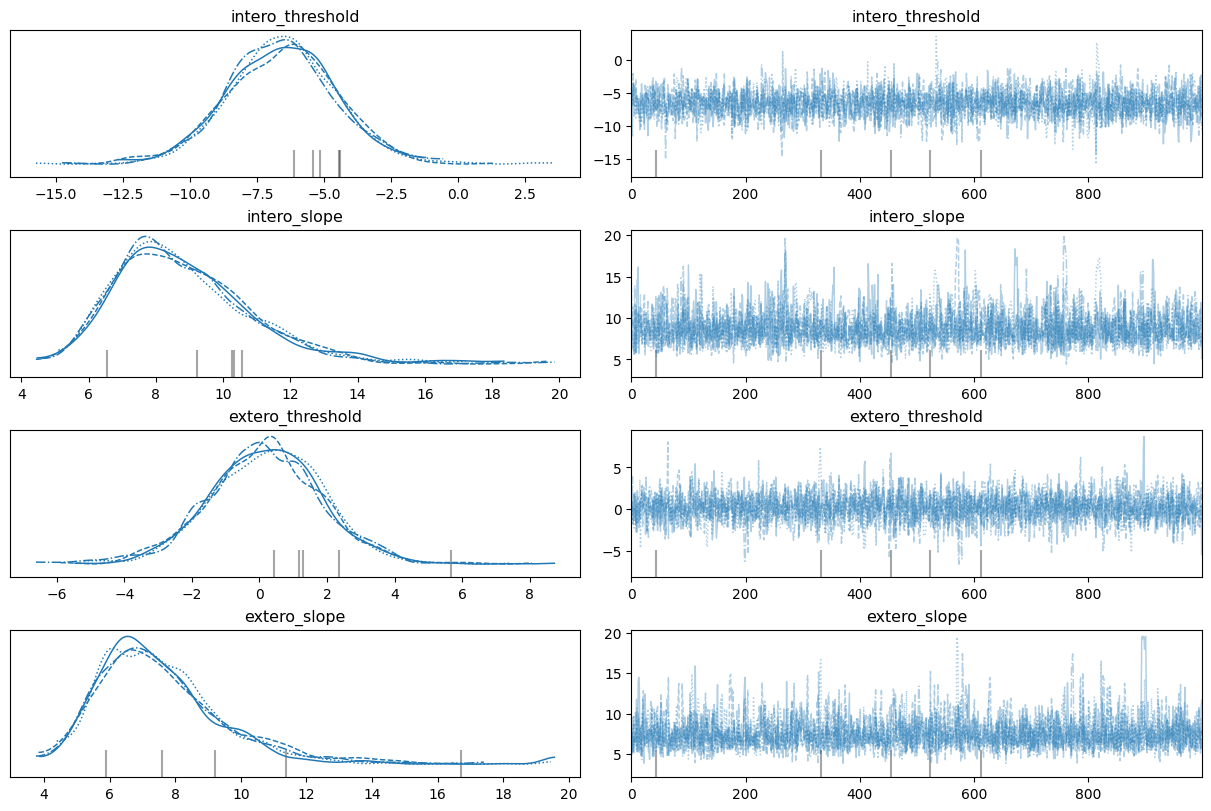

In [6]:
az.plot_trace(
    idata_standard_model,
    var_names=["intero_threshold", "intero_slope", "extero_threshold", "extero_slope"],
);

In [7]:
with pm.Model() as shared_perceptive_noise:
    # exteroception ------------------------------
    extero_threshold = pm.Uniform("extero_threshold", lower=-50, upper=50)
    extero_slope = pm.Uniform("extero_slope", lower=0.1, upper=20)
    theta_extero = pm.Deterministic(
        "theta_extero",
        cumulative_normal(
            extero_tone_2 - extero_tone_1,
            extero_threshold,
            pt.sqrt(2 * extero_slope**2),
        ),
    )
    bin_extero = pm.Binomial(
        "bin_extero", p=theta_extero, n=1, observed=extero_decision
    )

    # interoception ------------------------------
    intero_threshold = pm.Uniform("intero_threshold", lower=-50, upper=50)
    intero_slope = pm.Uniform("intero_slope", lower=0.1, upper=20)
    theta_intero = pm.Deterministic(
        "theta_intero",
        cumulative_normal(
            intero_tone_2 - heart_rate,
            intero_threshold,
            pt.sqrt(extero_slope**2 + intero_slope**2),
        ),
    )
    bin_intero = pm.Binomial(
        "bin_intero", p=theta_intero, n=1, observed=intero_decision
    )

    idata_shared_perceptive_noise = pm.sample(
        chains=4,
        cores=4,
        tune=1000,
        draws=1000,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [extero_threshold, extero_slope, intero_threshold, intero_slope]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


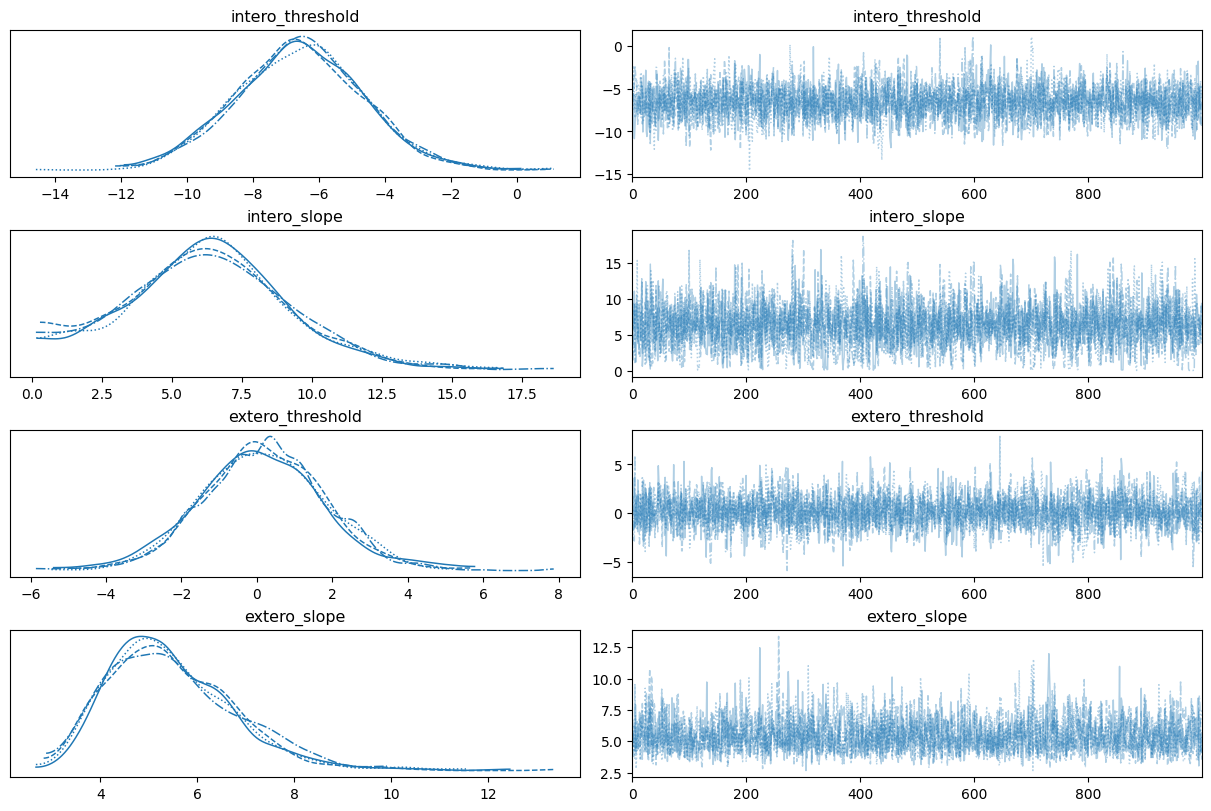

In [8]:
az.plot_trace(
    idata_shared_perceptive_noise,
    var_names=["intero_threshold", "intero_slope", "extero_threshold", "extero_slope"],
);

## Weighted Bayesian update

In [9]:
with pm.Model() as weigthed_update:
    # exteroception ------------------------------
    extero_threshold = pm.Uniform("extero_threshold", lower=-50, upper=50)
    extero_slope = pm.Uniform("extero_slope", lower=0.1, upper=30)
    theta_extero = pm.Deterministic(
        "theta_extero",
        cumulative_normal(
            extero_tone_2 - extero_tone_1,
            extero_threshold,
            pt.sqrt(2 * extero_slope**2),
        ),
    )
    bin_extero = pm.Binomial(
        "bin_extero", p=theta_extero, n=1, observed=extero_decision
    )

    # interoception ------------------------------
    # define cardiac priors
    mu_cardiac_prior = pm.Uniform("mu_cardiac_prior", lower=20, upper=150)
    sigma_cardiac_prior = pm.Uniform("sigma_cardiac_prior", lower=0.1, upper=30)

    interoceptive_precision = 2.0
    interoceptive_sensitivity = pm.Beta("interoceptive_sensitivity", 1, 1)

    # update cardiac beliefs using physiological inputs
    sigma_cardiac_belief = pm.Deterministic(
        "sigma_cardiac_belief",
        pt.sqrt(
            1
            / (
                (1 / sigma_cardiac_prior**2)
                + (interoceptive_sensitivity / interoceptive_precision**2)
            )
        ),
    )
    mu_cardiac_belief = pm.Deterministic(
        "mu_cardiac_belief",
        sigma_cardiac_belief**2
        * (
            mu_cardiac_prior / (sigma_cardiac_prior**2)
            + (interoceptive_sensitivity * heart_rate / interoceptive_precision)
        ),
    )

    theta_intero = pm.Deterministic(
        "theta_intero",
        1.0
        - cumulative_normal(
            0.0,
            intero_tone_2 - mu_cardiac_belief,
            pt.sqrt(sigma_cardiac_belief**2 + extero_slope**2),
        ),
    )
    bin_intero = pm.Binomial(
        "bin_intero", p=theta_intero, n=1, observed=intero_decision
    )

    idata_weigthed_update = pm.sample(
        chains=4,
        cores=4,
        tune=1000,
        draws=1000,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [extero_threshold, extero_slope, mu_cardiac_prior, sigma_cardiac_prior, interoceptive_sensitivity]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.
There were 250 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


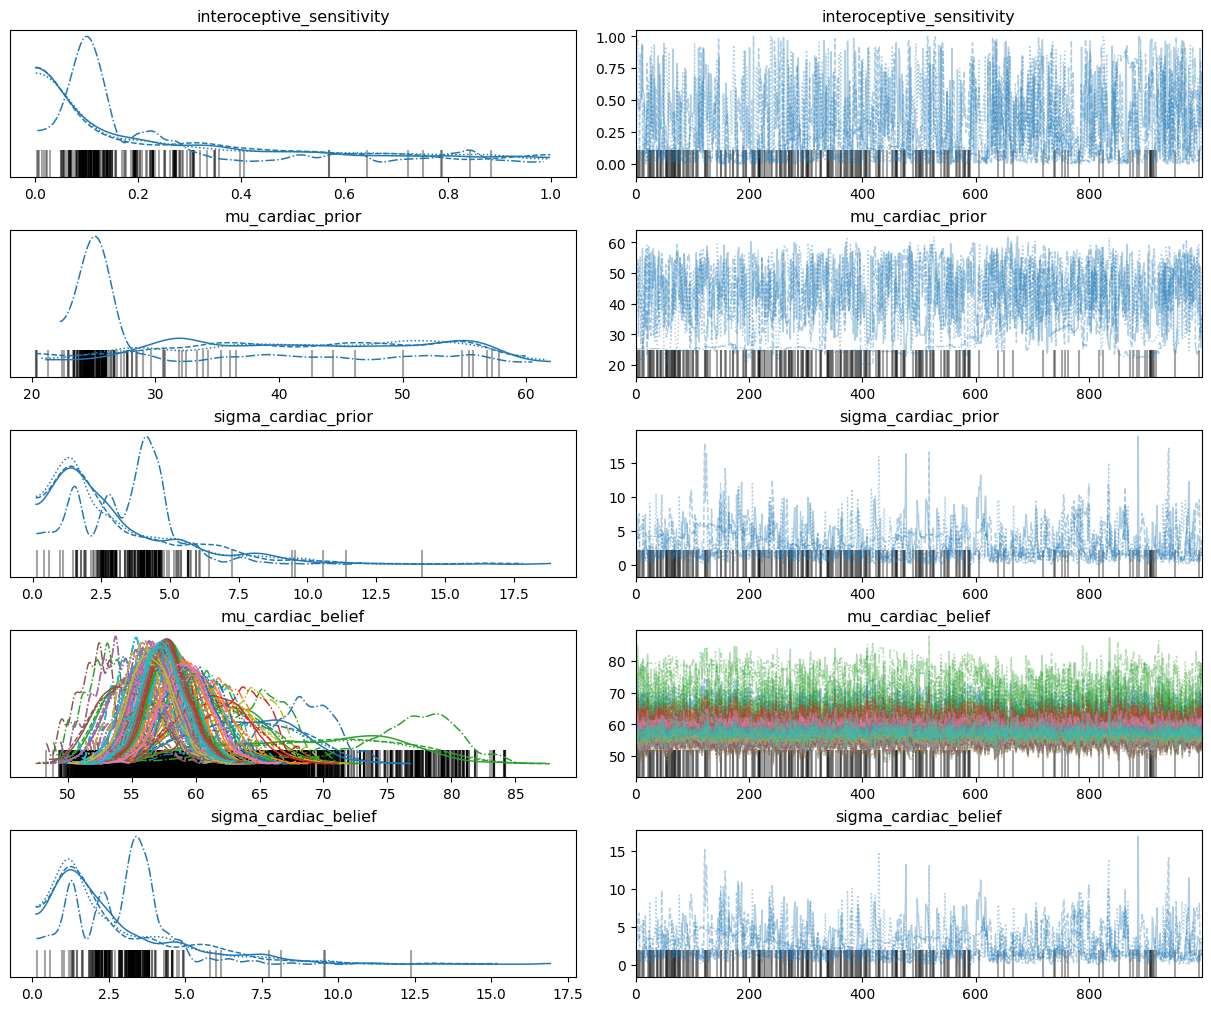

In [10]:
az.plot_trace(
    idata_weigthed_update,
    var_names=[
        "interoceptive_sensitivity",
        "mu_cardiac_prior",
        "sigma_cardiac_prior",
        "mu_cardiac_belief",
        "sigma_cardiac_belief",
    ],
);

In [11]:
model_compare = az.compare(
    {
        "standard": idata_standard_model,
        "shared_noise": idata_shared_perceptive_noise,
        "weigthed_update": idata_weigthed_update,
    },
    var_name="bin_intero",
)

/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

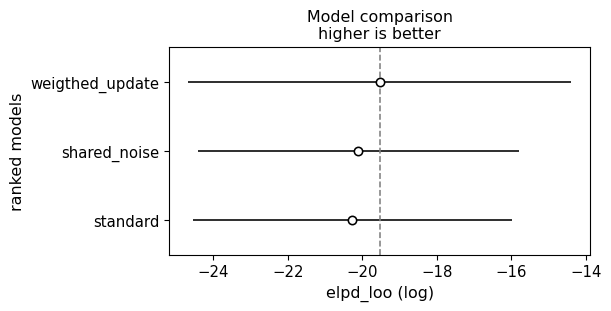

In [12]:
az.plot_compare(model_compare)